In [5]:
from google.colab import files
uploaded = files.upload()

Saving 1000_Companies.csv to 1000_Companies.csv
Saving canada_per_capita_income.csv to canada_per_capita_income.csv
Saving hiring.csv to hiring.csv
Saving homeprices_Multiple_LR.csv to homeprices_Multiple_LR.csv
Saving housing_area_price.csv to housing_area_price.csv
Saving salary.csv to salary.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])

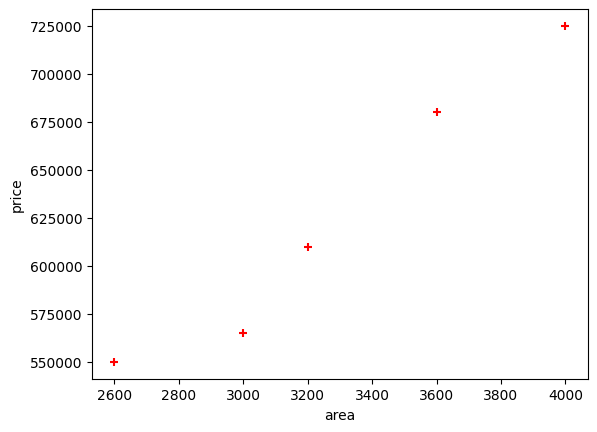

In [6]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt


df = pd.read_csv('housing_area_price.csv')
df

# Commented out IPython magic to ensure Python compatibility.
# %matplotlib inline
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price,color='red',marker='+')

new_df = df.drop('price',axis='columns')
new_df

price = df.price
price

# Create linear regression object
reg = linear_model.LinearRegression()
reg.fit(new_df,price)

"""(1) Predict price of a home with area = 3300 sqr ft"""

reg.predict([[3300]])

reg.coef_

reg.intercept_

"""Y = m * X + b (m is coefficient and b is intercept)"""

3300*135.78767123 + 180616.43835616432

"""(1) Predict price of a home with area = 5000 sqr ft"""

reg.predict([[5000]])

In [7]:
import pandas as pd
import numpy as np
from sklearn import linear_model

df = pd.read_csv('homeprices_Multiple_LR.csv')
df

"""Data Preprocessing: Fill NA values with median value of a column"""

df.bedrooms.median()

df.bedrooms = df.bedrooms.fillna(df.bedrooms.median())
df

reg = linear_model.LinearRegression()
reg.fit(df.drop('price',axis='columns'),df.price)

reg.coef_

reg.intercept_

"""Find price of home with 3000 sqr ft area, 3 bedrooms, 40 year old"""

reg.predict([[3000, 3, 40]])

112.06244194*3000 + 23388.88007794*3 + -3231.71790863*40 + 221323.00186540384

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


498408.25157402386

   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583

Coefficient: 828.4650752227104
Intercept: -1632210.7578554575
Equation: Income = 828.47 * Year + -1632210.76

Predicted per capita income in 2020: 41288.69409441762


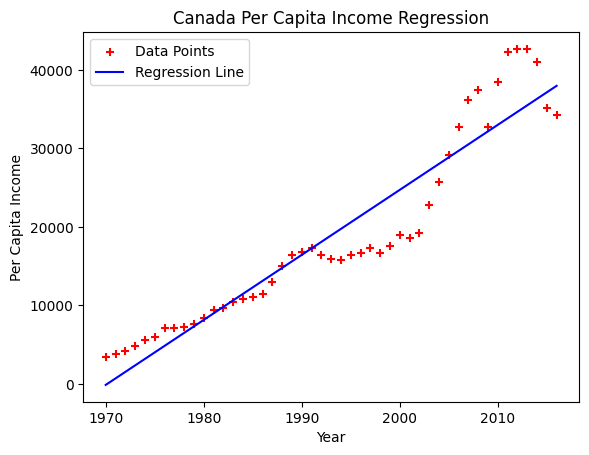

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('canada_per_capita_income.csv')

print(df.head())

# Prepare data
X = df[['year']]
y = df['per capita income (US$)']

# Train model
model = LinearRegression()
model.fit(X, y)

# Get equation
m = model.coef_[0]
b = model.intercept_

print("\nCoefficient:", m)
print("Intercept:", b)
print(f"Equation: Income = {m:.2f} * Year + {b:.2f}")

# Predict income for 2020
prediction = model.predict(pd.DataFrame({'year':[2020]}))
print("\nPredicted per capita income in 2020:", prediction[0])

# Plot graph
plt.scatter(df['year'], df['per capita income (US$)'], color='red', marker='+', label='Data Points')
plt.plot(df['year'], model.predict(X), color='blue', label='Regression Line')

plt.xlabel('Year')
plt.ylabel('Per Capita Income')
plt.title('Canada Per Capita Income Regression')
plt.legend()

plt.show()

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891

Coefficient (m): 9398.640601843543
Intercept (b): 26265.98773185531
Equation: Salary = 9398.64 * Experience + 26265.99


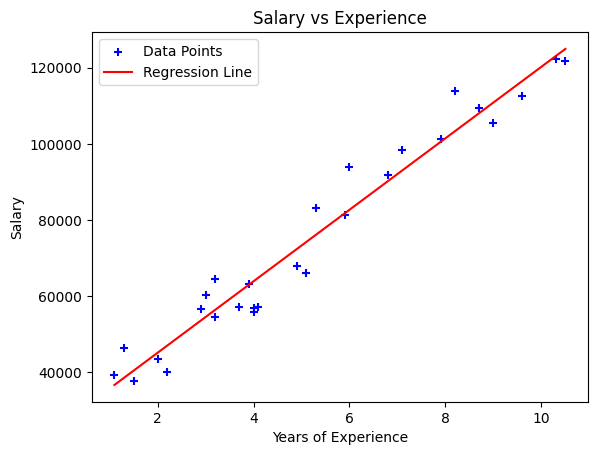


Predicted salary for 12 years experience: 139049.6749539778


In [18]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('salary.csv')

# Display dataset
print(df.head())

# Remove missing values
df = df.dropna()

# Plot scatter points
plt.scatter(df['YearsExperience'], df['Salary'], color='blue', marker='+', label='Data Points')

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')

# Prepare data
X = df[['YearsExperience']]
y = df['Salary']

# Train model
model = LinearRegression()
model.fit(X, y)

# Get coefficient and intercept
m = model.coef_[0]
b = model.intercept_

print("\nCoefficient (m):", m)
print("Intercept (b):", b)

# Print equation
print(f"Equation: Salary = {m:.2f} * Experience + {b:.2f}")

# Plot regression line
plt.plot(df['YearsExperience'], model.predict(X), color='red', label='Regression Line')

plt.legend()
plt.show()

# Predict salary for 12 years experience
prediction = model.predict(pd.DataFrame({'YearsExperience':[12]}))

print("\nPredicted salary for 12 years experience:", prediction[0])

In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('hiring.csv')

print("Original dataset:")
print(df)

# Step 1: Convert words to numbers in experience column
word_to_num = {
    'zero':0, 'one':1, 'two':2, 'three':3, 'four':4,
    'five':5, 'six':6, 'seven':7, 'eight':8,
    'nine':9, 'ten':10, 'eleven':11, 'twelve':12
}

df['experience'] = df['experience'].replace(word_to_num)

# Convert to numeric and fill missing values
df['experience'] = pd.to_numeric(df['experience'])
df['experience'] = df['experience'].fillna(0)

# Step 2: Fill missing test_score with mean
df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(
    df['test_score(out of 10)'].mean()
)

# Step 3: Define input and output
X = df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]
y = df['salary($)']

# Step 4: Train model
model = LinearRegression()
model.fit(X, y)

# Step 5: Get coefficients and intercept
b0 = model.intercept_
b1, b2, b3 = model.coef_

print("\nIntercept (b0):", b0)
print("Coefficient for Experience (b1):", b1)
print("Coefficient for Test Score (b2):", b2)
print("Coefficient for Interview Score (b3):", b3)

# Print equation
print("\nRegression Equation:")
print(f"Salary = {b0:.2f} + ({b1:.2f} × Experience) + ({b2:.2f} × TestScore) + ({b3:.2f} × InterviewScore)")

# Step 6: Predict salaries
salary1 = model.predict([[2, 9, 6]])
salary2 = model.predict([[12, 10, 10]])

print("\nPredicted salary for candidate 1:", salary1[0])
print("Predicted salary for candidate 2:", salary2[0])

Original dataset:
  experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0        NaN                    8.0                           9      50000
1        NaN                    8.0                           6      45000
2       five                    6.0                           7      60000
3        two                   10.0                          10      65000
4      seven                    9.0                           6      70000
5      three                    7.0                          10      62000
6        ten                    NaN                           7      72000
7     eleven                    7.0                           8      80000

Intercept (b0): 17237.330313727172
Coefficient for Experience (b1): 2827.63404314351
Coefficient for Test Score (b2): 1912.9380305338782
Coefficient for Interview Score (b3): 2196.975314104758

Regression Equation:
Salary = 17237.33 + (2827.63 × Experience) + (1912.94 × TestScore) + (2196.98 × InterviewSc

/tmp/ipython-input-396224040.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['experience'] = df['experience'].replace(word_to_num)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [20]:
# Multiple Linear Regression - Company Profit Prediction

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('1000_Companies.csv')

print("Original dataset:")
print(df.head())

# Convert categorical variable 'State' into dummy variables
df = pd.get_dummies(df, columns=['State'], drop_first=True)

print("\nDataset after encoding:")
print(df.head())

# Define independent and dependent variables
X = df.drop('Profit', axis=1)
y = df['Profit']

# Train model
model = LinearRegression()
model.fit(X, y)

# Get intercept and coefficients
intercept = model.intercept_
coefficients = model.coef_
feature_names = X.columns

print("\nIntercept (b0):", intercept)

print("\nCoefficients:")
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef}")

# Print full equation
print("\nRegression Equation:")
equation = f"Profit = {intercept:.2f}"
for name, coef in zip(feature_names, coefficients):
    equation += f" + ({coef:.2f} × {name})"

print(equation)

# Predict profit for given input
# Florida example
# Check encoded columns order
print("\nFeature order:", list(feature_names))

# Create input in correct order
input_data = pd.DataFrame({
    'R&D Spend':[91694.48],
    'Administration':[515841.3],
    'Marketing Spend':[11931.24],
    'State_Florida':[1],
    'State_New York':[0]
})

profit = model.predict(input_data)

print("\nPredicted profit:", profit[0])

Original dataset:
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94

Dataset after encoding:
   R&D Spend  Administration  Marketing Spend     Profit  State_Florida  \
0  165349.20       136897.80        471784.10  192261.83          False   
1  162597.70       151377.59        443898.53  191792.06          False   
2  153441.51       101145.55        407934.54  191050.39           True   
3  144372.41       118671.85        383199.62  182901.99          False   
4  142107.34        91391.77        366168.42  166187.94           True   

   State_New York  
0            True  
1           False  
2           False  
3           